## Continuous wavelet transform:

It allows us to analyze a signal into different frequencies at different time resolutions by using a window function of a wavepacket (called a wavelet here). It can be shifted, shrunken (capture details of the signal) and stretched (capture overall trend of the signal).
Set of methods to carry out spectral analysis in the time domain, it's a multi-resolution analysis.

$$
\begin{equation}
X(\tau, s) = \frac{1}{\sqrt{|s|}} \int_{-\infty}^{\infty} x(t) \, \overline{\psi\left( \frac{t - \tau}{s} \right)} \, dt
\end{equation}
$$


## Discrete wavelet transform:

### Approximation coefficients (A): 
* Wavelets with large values of $s$, they're stretched.
* They represent the low-frequency parts of the signal, the overall trend.
### Detail coefficients (D):
* Wavelets with small values of $s$, they're compressed.
* They represent the high-frequency parts of the signal, the details or sharp features.

The WT calculates these coefficients at all scales, while the DWT takes $s$ and $\tau$ as discrete values, which reduces the amount of data. $s$ and $\tau$ are usually powers of dyadics.

$$
\begin{equation}
X(\tau, s) = \frac{1}{\sqrt{s}} \sum_{i = 0}^{p - 1} x[t_i] \ \psi [\frac{t_i - \tau}{s}]
\end{equation}
$$
where,

$\tau = k \ 2^{-j}$

$s = 2^{-j}$

p: number of WT coefficients.

j: index of scaling.

k: index of WT coefficients.


### Multilevel decomposition of the DWT:
It's based on repeatedly decomposing a signal into a low-frequency part (A) and a high-frequency part (D). We do this for each level (tree-like structure) until there is no clear difference between the elements of $A$ and $D$.

### Example 1:

Let's carry out a Discrete Wavelet Transform of this signal:

$f(n) = (2, 4, 6, 8, 9, -2, 3, -4)$ 

Then, carry out an inverse DWT to recover the signal.

In [1]:
import pywt
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
import IPython.display as ipd

# https://pywavelets.readthedocs.io/en/latest/

In [3]:
# signal:

f = [2, 4, 6, 8, 9, -2, 3, -4, -7]

print(f, len(f))

[2, 4, 6, 8, 9, -2, 3, -4, -7] 9


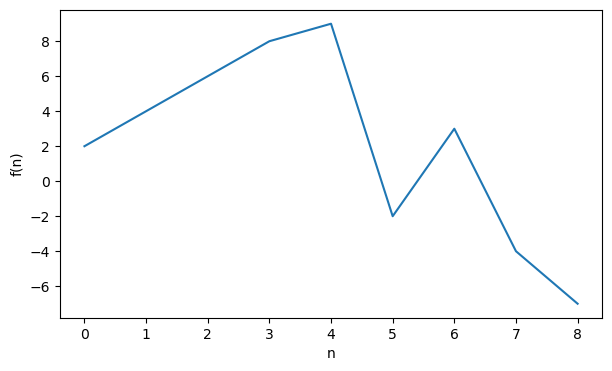

In [4]:
plt.figure(figsize=(7,4))

plt.plot(f)

plt.xlabel("n")
plt.ylabel("f(n)")

plt.show()

In [5]:
# DWT:

cA, cD = pywt.dwt(f, 'haar')

In [6]:
print(cA) # approximation coef.
print(cD) # detail coef.

[ 4.24264069  9.89949494  4.94974747 -0.70710678 -9.89949494]
[-1.41421356e+00 -1.41421356e+00  7.77817459e+00  4.94974747e+00
 -3.33066907e-16]


The coefficients arrays have the same size, which is approximately half the length of the signal on the 1st level.

In [7]:
# iDWT

f_recovered = pywt.idwt(cA, cD, 'haar')

In [8]:
print(f)
print(f_recovered)

[2, 4, 6, 8, 9, -2, 3, -4, -7]
[ 2.  4.  6.  8.  9. -2.  3. -4. -7. -7.]


### Example 2:

$$f(x) = A \sin(kx) + n(x)$$

In [9]:
# Pure sine function
def func (x, a, k, b):
    """
    Inputs: 
        a -> amplitude of the sine function
        k -> wavenumber
        b -> noise amplitude      
    """
    f_sin = a*np.sin(k*x) + b*np.random.randn(len(x))

    return f_sin

In [10]:
# Generate x axis
x = np.linspace(0., 4*np.pi, 1000)

# Fix parameters
a = 1.
k = 2./(np.pi)
b = 0.1

# Evaluate our function
noisy_sine = func(x, a, k, b)

# Safe check
print(x.shape, noisy_sine.shape)

(1000,) (1000,)


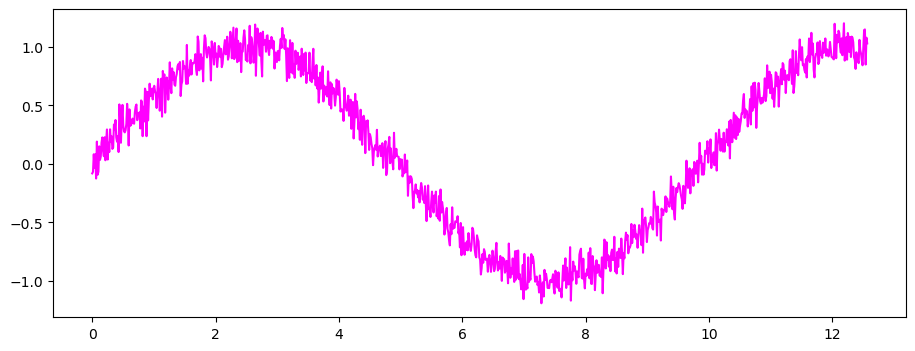

In [11]:
# Plotting
plt.figure(figsize = (11, 4))
plt.plot(x, noisy_sine, color = "magenta")
plt.show()

In [12]:
# DWT:

cA, cD = pywt.dwt(noisy_sine, 'haar') #one level

print(noisy_sine.shape, cA.shape, cD.shape)

(1000,) (500,) (500,)


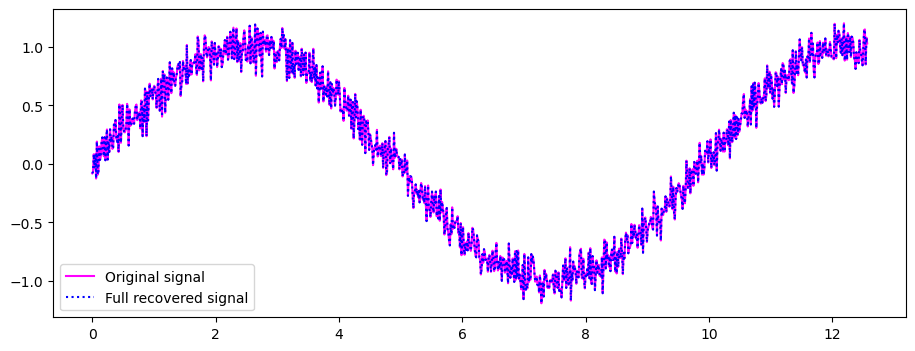

In [13]:
# iDWT
sine_recovered = pywt.idwt(cA, cD, 'haar')

# Plotting
plt.figure(figsize = (11, 4))
plt.plot(x, noisy_sine, color = "magenta", label = "Original signal")
plt.plot(x, sine_recovered, linestyle  = ":", color = "blue", label = "Full recovered signal")

plt.legend()
plt.show()

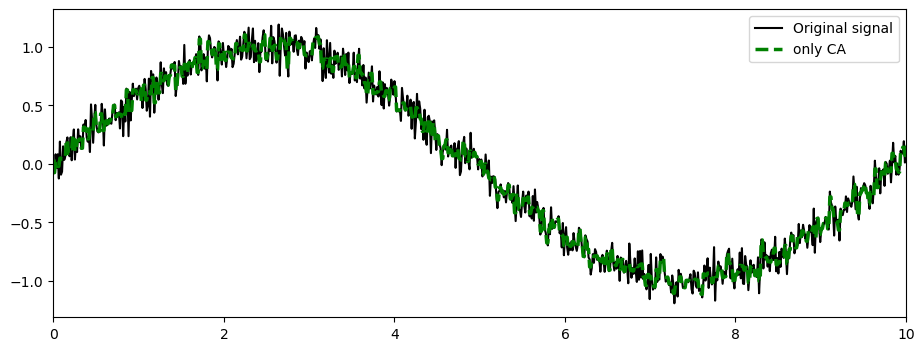

In [14]:
# Only low-frequencies
# iDWT
ca_recovered = pywt.idwt(cA, None, 'haar')

# Plotting
plt.figure(figsize = (11, 4))
plt.plot(x, noisy_sine, color = "black", label = "Original signal")
plt.plot(x, ca_recovered, linestyle  = "--", linewidth = 2.5, color = "green", label = "only CA")

plt.xlim(0, 10)
plt.legend()
plt.show()

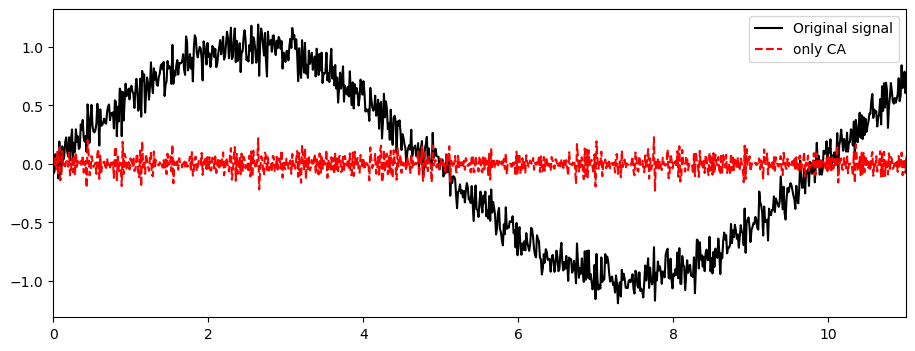

In [15]:
# Only high-frequencies
# iDWT
cd_recovered = pywt.idwt(None, cD, 'haar')

# Plotting
plt.figure(figsize = (11, 4))
plt.plot(x, noisy_sine, color = "black", label = "Original signal")
plt.plot(x, cd_recovered, linestyle  = "--", linewidth = 1.5, color = "red", label = "only CA")

plt.xlim(0, 11)
plt.legend()
plt.show()

## Wavelet transform analysis:

``python
coeffs = pywt.wavedec(x, 'wavelet', mode ='sym', level = n)
``


``python
y = pywt.waverec(coeffs, 'wavelet', mode ='sym')
``

#### https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html

### Revisit Example 1:

In [16]:
#DWT
coeffs = pywt.wavedec(f, 'db1', level = 2, mode = 'periodic')

cA2, cD2, cD1 = coeffs

print(cA2.shape) #second level
print(cD2.shape) #second level
print(cD1.shape) #first level

(3,)
(3,)
(5,)


In [17]:
#DWT reconstruction
f_recovered2 = pywt.waverec(coeffs, 'db1', mode = 'periodic')

In [18]:
print(f)
print(f_recovered2) #we get an extra element if the len of the signal is not even

[2, 4, 6, 8, 9, -2, 3, -4, -7]
[ 2.  4.  6.  8.  9. -2.  3. -4. -7.  2.]


### Revisit Example 2:

In [23]:
#DWT
coeffs = pywt.wavedec(noisy_sine, 'db1', level = 2, mode = 'periodic')

cA2, cD2, cD1 = coeffs

print(cA2.shape) #second level
print(cD2.shape) #second level
print(cD1.shape) #first level

(250,)
(250,)
(500,)


In [22]:
#DWT reconstruction
sine_recovered2 = pywt.waverec(coeffs, 'db1', mode = 'periodic')